# KPI 1 y KPI 2 — Servicio Ciudadano 1800
Carga los datasets desde SQL Server (Docker) y muestra los 2 indicadores aprobados: Tasa de Recontacto en 7 Días (TR7D) y Duración Promedio de Interacción (DPI), desagregados por sus dimensiones.

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
from cargar_datos import cargar_kpi_recontacto, cargar_kpi_duracion

df_recontacto = cargar_kpi_recontacto()
df_duracion = cargar_kpi_duracion()

📊 CARGANDO DATASET — KPI 1: Tasa de Recontacto en 7 Días



📏 Dimensiones: 354 filas × 10 columnas

🎯 TR7D global: 38.14%

📈 TR7D por canal:
canal
(sin dato)    44.44
Chat          45.36
Correo        28.79
Red social    44.26
Teléfono      33.88
Name: recontacto_7_dias, dtype: float64

📈 TR7D por motivo:
motivo_contacto
Cobro        31.82
Consulta     32.79
Falla        50.00
Queja        34.21
Solicitud    40.96
Name: recontacto_7_dias, dtype: float64

📈 TR7D por cola de servicio:
cola_servicio
Facturación    40.30
Información    33.68
Reclamos       40.32
Soporte        39.74
Trámites       38.46
Name: recontacto_7_dias, dtype: float64

📊 CARGANDO DATASET — KPI 2: Duración Promedio de Interacción

📏 Dimensiones: 360 filas × 9 columnas

🎯 DPI global: 966.4 seg (16.1 min)

📈 DPI por canal:
canal
(sin dato)     983.2
Chat          1061.9
Correo         919.2
Red social     878.9
Teléfono       960.9
Name: duracion_seg, dtype: float64


/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)
/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)


## KPI 1 — Tasa de Recontacto en 7 Días (TR7D)

In [2]:
tr7d_global = df_recontacto['recontacto_7_dias'].mean() * 100
print(f"TR7D global: {tr7d_global:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

(df_recontacto.groupby('canal')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[0], title='TR7D por canal')
(df_recontacto.groupby('motivo_contacto')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[1], title='TR7D por motivo')
(df_recontacto.groupby('cola_servicio')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[2], title='TR7D por cola')

for ax in axes:
    ax.set_xlabel('%')
plt.tight_layout()
plt.show()

TR7D global: 38.14%


<Figure size 1600x400 with 3 Axes>

## KPI 1 — Tendencia mensual

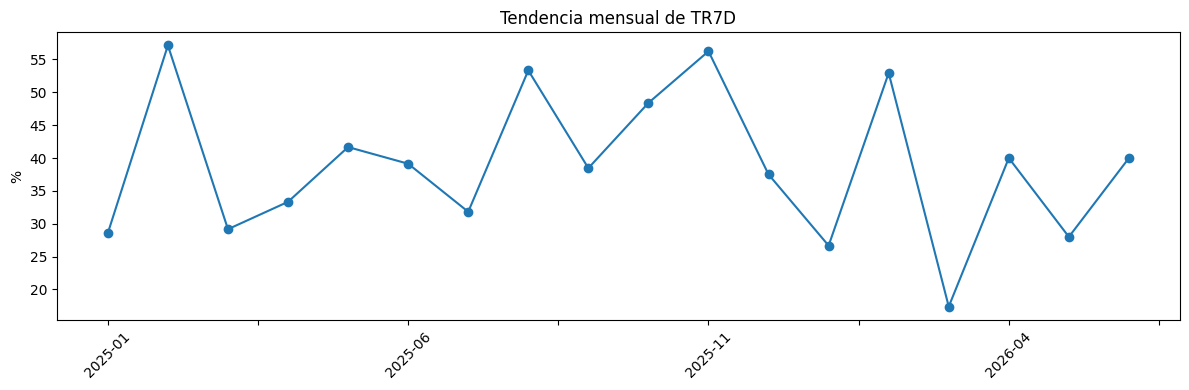

In [3]:
tendencia = (df_recontacto.groupby(['anio', 'mes'])['recontacto_7_dias'].mean() * 100)
tendencia.index = [f"{a}-{m:02d}" for a, m in tendencia.index]
tendencia.plot(figsize=(12, 4), marker='o', title='Tendencia mensual de TR7D')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## KPI 2 — Duración Promedio de Interacción (DPI)

DPI global: 966.4 seg (16.1 min)


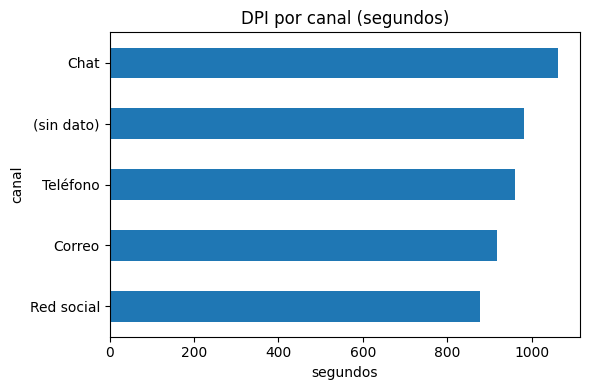

In [4]:
dpi_global = df_duracion['duracion_seg'].mean()
print(f"DPI global: {dpi_global:.1f} seg ({dpi_global/60:.1f} min)")

df_duracion.groupby('canal')['duracion_seg'].mean().sort_values().plot(
    kind='barh', figsize=(6, 4), title='DPI por canal (segundos)')
plt.xlabel('segundos')
plt.tight_layout()
plt.show()

## Cruce KPI1 x KPI2 (hipótesis a validar con minería, no es un hallazgo confirmado)

In [5]:
resumen = df_recontacto.groupby('canal')['recontacto_7_dias'].mean().mul(100).rename('TR7D_%')
resumen = resumen.to_frame().join(df_duracion.groupby('canal')['duracion_seg'].mean().rename('DPI_seg'))
resumen

,TR7D_%,DPI_seg
canal,,
(sin dato),44.444444,983.222222
Chat,45.360825,1061.876289
Correo,28.787879,919.242424
Red social,44.262295,878.859375
Teléfono,33.884298,960.911290
